# Kappa Estimation & Fill Probability Analysis

Estimates the GLFT fill-sensitivity parameter κ from BTC/USDT tick data using two approaches:

**Approach A — Market trade curve:** For each market trade, measure distance from mid.
P(fill | δ) = fraction of all trades reaching distance δ. Full exponential fit including 0.5-tick.

**Approach B — Execution simulation:** Place synthetic orders at each requote interval
(respecting latency and exposure window) and check fills against actual trade data.
This is calibrated to *your specific execution parameters* and is the most relevant κ for strategy use.

**Model:** `λ(δ) = A × exp(-κ × δ)` where δ is distance from mid in ticks.

## Sections
1. Setup & data loading
2. Core functions
3. Approach A — market trade curve (full day)
4. Approach A — rolling windows & regime analysis
5. Approach B — execution-aware simulation
6. Comparison A vs B
7. GLFT plug-in — implied spreads
8. Summary

## 1. Setup & Data Loading

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
from scipy.stats import spearmanr
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import sys
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
print(f'Project root: {ROOT}')

from hft_market_maker.strategies.glft import GLFTMarketMaker

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

# ── Global config ──────────────────────────────────────────────────
DATA_DIR        = Path('../data/real')
DATE            = '2025-05-13'
DAYS            = ['2025-05-13', '2025-05-14', '2025-05-15',
                   '2025-05-16', '2025-05-17']
TICK            = 0.01    # BTC/USDT tick size in dollars
MAX_DELTA_TICKS = 40      # fit only first N ticks
MAX_QUOTE_AGE   = 200     # ms — drop trades with stale mid
ROLL_WINDOW     = 15      # minutes for rolling estimation
ROLL_STEP       = 5       # minutes between rolling windows
MIN_TRADES      = 200     # min trades per window to attempt fit
# Execution parameters for Approach B
LATENCY         = 0.10    # seconds
QUOTE_INTERVAL  = 0.50    # seconds
# ───────────────────────────────────────────────────────────────────

print('Setup complete')

Project root: /Users/adamlazinski/Desktop/master2
Setup complete


In [31]:
def load_day(date_str, data_dir=DATA_DIR):
    trades = pd.read_parquet(data_dir / f'trades_BTC_{date_str}.parquet')
    quotes = pd.read_parquet(data_dir / f'quotes_BTC_{date_str}.parquet')
    trades['ts'] = pd.to_datetime(trades['time_exchange'], utc=True)
    quotes['ts'] = pd.to_datetime(quotes['time_exchange'], utc=True)
    trades = trades.sort_values('ts').reset_index(drop=True)
    quotes = quotes.sort_values('ts').reset_index(drop=True)
    quotes['mid'] = (quotes['bid_price'] + quotes['ask_price']) / 2
    return trades, quotes

trades, quotes = load_day(DATE)
print(f'Trades: {len(trades):,}  |  Quotes: {len(quotes):,}')
print(f'Price range: ${trades["price"].min():.0f} - ${trades["price"].max():.0f}')

Trades: 3,476,024  |  Quotes: 681,990
Price range: $101430 - $104976


## 2. Core Functions

In [32]:
# ── Approach A ─────────────────────────────────────────────────────

def compute_fill_curve(trades, quotes,
                       max_quote_age_ms=MAX_QUOTE_AGE):
    """
    Merge mid + sigma onto each trade, compute distance from mid in ticks.
    Drops trades where mid is stale. Returns merged DataFrame.
    """
    q = quotes.copy()
    q['log_ret']          = np.log(q['mid']).diff()
    dt_sec                = q['ts'].diff().dt.total_seconds().clip(lower=1e-6)
    q['ret_per_sqrt_sec'] = q['log_ret'] / np.sqrt(dt_sec)
    q['sigma']            = q['ret_per_sqrt_sec'].rolling(200, min_periods=10).std()
    q['sigma_dollar']     = q['sigma'] * q['mid']

    merged = pd.merge_asof(
        trades[['ts', 'price', 'size']].sort_values('ts'),
        q[['ts', 'mid', 'sigma', 'sigma_dollar']].sort_values('ts')
          .rename(columns={'ts': 'quote_ts'}),
        left_on='ts', right_on='quote_ts', direction='backward'
    )
    merged = merged.dropna(subset=['mid', 'sigma_dollar'])
    merged['quote_age_ms'] = (
        merged['ts'] - merged['quote_ts']
    ).dt.total_seconds() * 1000
    merged = merged[merged['quote_age_ms'] < max_quote_age_ms]
    merged['delta_dollar'] = np.abs(merged['price'] - merged['mid'])
    merged['delta']        = merged['delta_dollar'] / TICK
    merged['hour']         = merged['ts'].dt.hour
    merged = merged[merged['delta'] > 0]
    return merged


def empirical_fill_prob(merged_all, max_delta_ticks=MAX_DELTA_TICKS):
    """P(fill | delta >= bin) using half-tick bins 0.5, 1.5, 2.5 ..."""
    all_deltas = merged_all['delta'].values
    bins = np.arange(0.5, max_delta_ticks + 0.5, 1.0)
    probs = [(b, (all_deltas >= b).mean()) for b in bins]
    df = pd.DataFrame(probs, columns=['delta', 'fill_prob'])
    return df[df['fill_prob'] > 0].reset_index(drop=True)


def fit_exponential(fp_df, min_delta=0.5):
    """
    Fit A * exp(-kappa * delta). min_delta controls which points to include.
    Returns (A, kappa, se_A, se_kappa, r2) or all None on failure.
    """
    df = fp_df[fp_df['delta'] >= min_delta].copy()
    if len(df) < 3:
        return None, None, None, None, None

    def model(delta, A, kappa):
        return A * np.exp(-kappa * delta)

    try:
        p0 = [df['fill_prob'].iloc[0], 0.5]
        popt, pcov = curve_fit(
            model, df['delta'].values, df['fill_prob'].values,
            p0=p0, bounds=([0, 1e-4], [5, 200]), maxfev=10000
        )
        A_hat, kappa_hat = popt
        se = np.sqrt(np.diag(pcov))
        y      = df['fill_prob'].values
        y_hat  = model(df['delta'].values, A_hat, kappa_hat)
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 1e-12 else 0.0
        return A_hat, kappa_hat, se[0], se[1], r2
    except Exception:
        return None, None, None, None, None


# ── Approach B ─────────────────────────────────────────────────────

def simulate_order_fills(trades, quotes,
                          half_spread_ticks,
                          latency=LATENCY,
                          quote_interval=QUOTE_INTERVAL,
                          max_quote_age_ms=MAX_QUOTE_AGE):
    """
    Simulate placing limit orders at half_spread_ticks from mid at every
    quote_interval with given latency. Exposure window = quote_interval seconds
    (cancel latency extends it by exactly as much as activation latency delays it).

    Returns (fill_rate, results_df).
    """
    half_spread = half_spread_ticks * TICK

    trades_ts  = (trades['ts'].astype(np.int64) / 1e9).values
    trades_px  = trades['price'].values
    quotes_ts  = (quotes['ts'].astype(np.int64) / 1e9).values
    quotes_mid = quotes['mid'].values

    t_min = trades_ts[0]
    t_max = trades_ts[-1]

    results = []
    t = t_min

    while t < t_max - quote_interval:
        # Most recent quote before t
        q_idx = np.searchsorted(quotes_ts, t, side='right') - 1
        if q_idx < 0:
            t += quote_interval
            continue

        # Drop stale quotes
        quote_age_ms = (t - quotes_ts[q_idx]) * 1000
        if quote_age_ms > max_quote_age_ms:
            t += quote_interval
            continue

        mid = quotes_mid[q_idx]
        bid = mid - half_spread
        ask = mid + half_spread

        # Exposure: [t+latency, t+quote_interval+latency]
        active_from = t + latency
        active_to   = t + quote_interval + latency

        lo = np.searchsorted(trades_ts, active_from, side='left')
        hi = np.searchsorted(trades_ts, active_to,   side='right')
        window_px = trades_px[lo:hi]

        bid_filled = bool(np.any(window_px <= bid))
        ask_filled = bool(np.any(window_px >= ask))

        results.append({
            'ts':         t,
            'mid':        mid,
            'bid_filled': bid_filled,
            'ask_filled': ask_filled,
            'any_filled': bid_filled or ask_filled,
            'n_window':   len(window_px),
        })
        t += quote_interval

    df = pd.DataFrame(results)
    fill_rate = df['any_filled'].mean() if len(df) > 0 else 0.0
    return fill_rate, df


def simulate_fill_curve(trades, quotes,
                         deltas=None,
                         latency=LATENCY,
                         quote_interval=QUOTE_INTERVAL,
                         verbose=True):
    """Sweep spread distances and return fill rate DataFrame."""
    if deltas is None:
        deltas = np.arange(0.5, MAX_DELTA_TICKS + 0.5, 1.0)
    rows = []
    for d in deltas:
        rate, _ = simulate_order_fills(
            trades, quotes, half_spread_ticks=d,
            latency=latency, quote_interval=quote_interval
        )
        rows.append({'delta': d, 'fill_prob': rate})
        if verbose:
            print(f'  delta={d:.1f} ticks: fill_rate={rate:.4f}')
    return pd.DataFrame(rows)


print('All functions defined')

All functions defined


## 3. Approach A — Market Trade Curve (Full Day)

In [33]:
merged_all = compute_fill_curve(trades, quotes)
print(f'Fresh trades: {len(merged_all):,} / {len(trades):,} '
      f'({len(merged_all)/len(trades)*100:.1f}% pass staleness filter)')

fp_A = empirical_fill_prob(merged_all)
A_hat, kappa_hat, se_A, se_kappa, r2 = fit_exponential(fp_A, min_delta=0.5)

print(f'\nApproach A — full-day (all ticks from 0.5):')
print(f'  A     = {A_hat:.4f}  (+-{se_A:.4f})')
print(f'  kappa = {kappa_hat:.4f}  (+-{se_kappa:.4f})  [1/tick]')
print(f'  R2    = {r2:.4f}')
print(f'  Halves every {np.log(2)/kappa_hat:.2f} ticks')
print()
print(fp_A.to_string(index=False))

Fresh trades: 3,411,517 / 3,476,024 (98.1% pass staleness filter)

Approach A — full-day (all ticks from 0.5):
  A     = 0.4694  (+-0.0222)
  kappa = 0.0071  (+-0.0022)  [1/tick]
  R2    = 0.2053
  Halves every 97.91 ticks

 delta  fill_prob
   0.5   0.848491
   1.5   0.441042
   2.5   0.421809
   3.5   0.417848
   4.5   0.414401
   5.5   0.413435
   6.5   0.412467
   7.5   0.410466
   8.5   0.409517
   9.5   0.408668
  10.5   0.406785
  11.5   0.405863
  12.5   0.405028
  13.5   0.403569
  14.5   0.402798
  15.5   0.401267
  16.5   0.400508
  17.5   0.399703
  18.5   0.398121
  19.5   0.397273
  20.5   0.396405
  21.5   0.394746
  22.5   0.394132
  23.5   0.393345
  24.5   0.391904
  25.5   0.391237
  26.5   0.389657
  27.5   0.388986
  28.5   0.388343
  29.5   0.386934
  30.5   0.386160
  31.5   0.385458
  32.5   0.384001
  33.5   0.383253
  34.5   0.382526
  35.5   0.381173
  36.5   0.380477
  37.5   0.379655
  38.5   0.378236
  39.5   0.377477


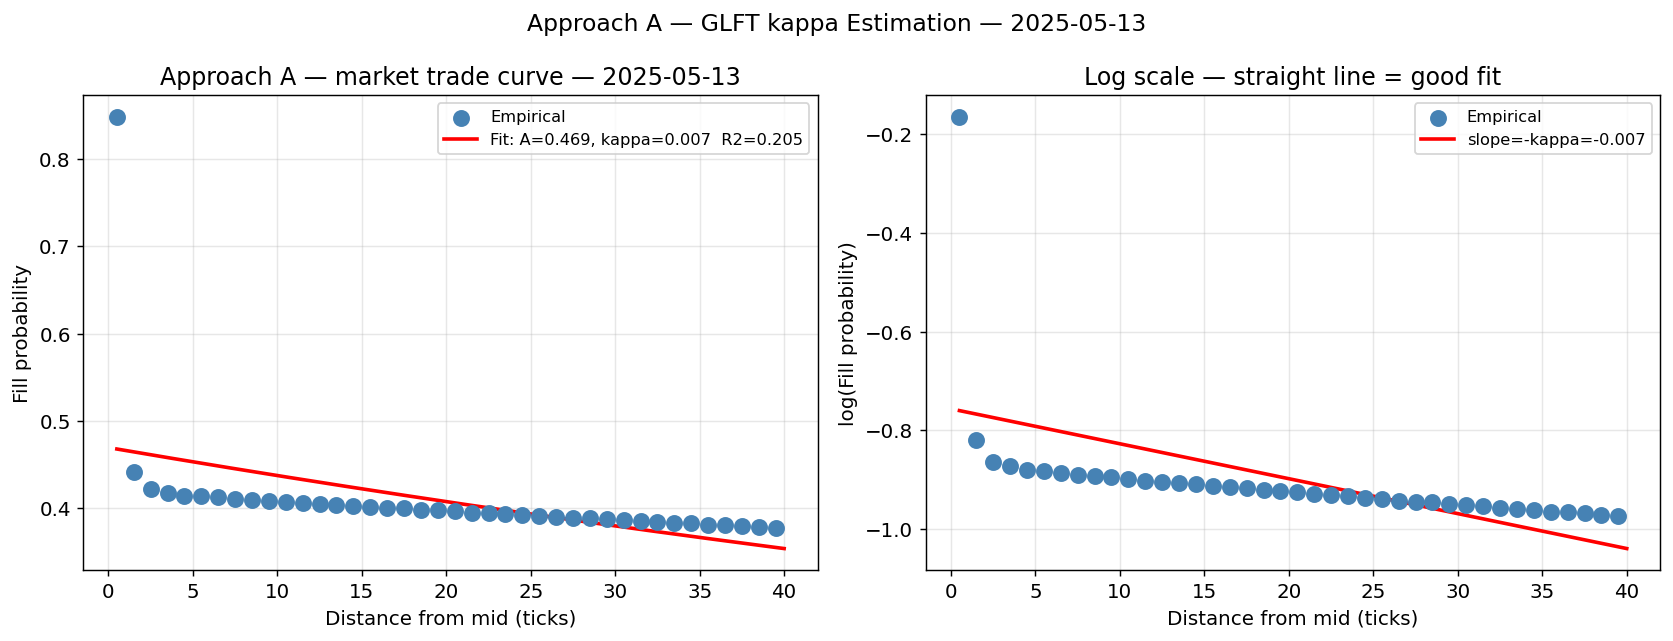

In [34]:
delta_range = np.linspace(0.5, MAX_DELTA_TICKS, 300)
fitted_A    = A_hat * np.exp(-kappa_hat * delta_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(fp_A['delta'], fp_A['fill_prob'], s=70, zorder=3, color='steelblue', label='Empirical')
axes[0].plot(delta_range, fitted_A, 'r-', lw=2,
             label=f'Fit: A={A_hat:.3f}, kappa={kappa_hat:.3f}  R2={r2:.3f}')
axes[0].set_xlabel('Distance from mid (ticks)')
axes[0].set_ylabel('Fill probability')
axes[0].set_title(f'Approach A — market trade curve — {DATE}')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

valid = fp_A[fp_A['fill_prob'] > 0]
axes[1].scatter(valid['delta'], np.log(valid['fill_prob']), s=70, zorder=3, color='steelblue', label='Empirical')
axes[1].plot(delta_range, np.log(fitted_A + 1e-10), 'r-', lw=2, label=f'slope=-kappa=-{kappa_hat:.3f}')
axes[1].set_xlabel('Distance from mid (ticks)')
axes[1].set_ylabel('log(Fill probability)')
axes[1].set_title('Log scale — straight line = good fit')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle(f'Approach A — GLFT kappa Estimation — {DATE}', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/kappa_fit_A_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Approach A — Rolling Windows & Regime Analysis

In [35]:
# Regime labels
merged_all['vol_quartile'] = pd.qcut(
    merged_all['sigma_dollar'], 4,
    labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)']
)

# Vol quartile fits
vol_results = []
for vq in ['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)']:
    sub = merged_all[merged_all['vol_quartile'] == vq]
    fp_sub = empirical_fill_prob(sub)
    A, k, se_A_v, se_k_v, r2_v = fit_exponential(fp_sub, min_delta=0.5)
    sig = sub['sigma_dollar'].mean()
    vol_results.append({'vol_quartile': vq, 'sigma_dollar': sig,
                        'A': A, 'kappa': k, 'se_A': se_A_v,
                        'se_kappa': se_k_v, 'r2': r2_v, 'n': len(sub)})
    print(f'{vq:<14} n={len(sub):>8,}  sigma={sig:.3f}  '
          f'A={A:.3f}(+-{se_A_v:.3f})  kappa={k:.3f}(+-{se_k_v:.3f})  R2={r2_v:.3f}')

vol_df = pd.DataFrame(vol_results).dropna(subset=['kappa'])

# Hourly fits
hour_results = []
for h in range(24):
    sub = merged_all[merged_all['hour'] == h]
    if len(sub) < MIN_TRADES:
        continue
    fp_sub = empirical_fill_prob(sub)
    A, k, se_A_h, se_k_h, r2_h = fit_exponential(fp_sub, min_delta=0.5)
    if k is not None:
        hour_results.append({'hour': h, 'A': A, 'kappa': k,
                              'se_A': se_A_h, 'se_kappa': se_k_h,
                              'r2': r2_h, 'n': len(sub),
                              'sigma_dollar': sub['sigma_dollar'].mean()})
hour_df = pd.DataFrame(hour_results)

Q1 (low)       n= 852,903  sigma=1.762  A=0.429(+-0.024)  kappa=0.008(+-0.003)  R2=0.202
Q2             n= 852,904  sigma=3.538  A=0.454(+-0.023)  kappa=0.008(+-0.002)  R2=0.206
Q3             n= 852,842  sigma=5.066  A=0.475(+-0.022)  kappa=0.007(+-0.002)  R2=0.200
Q4 (high)      n= 852,868  sigma=10.183  A=0.520(+-0.020)  kappa=0.006(+-0.002)  R2=0.215


In [36]:
# Rolling kappa — Approach A
def rolling_kappa_A(merged_all, window_min=ROLL_WINDOW, step_min=ROLL_STEP):
    results = []
    t_min = merged_all['ts'].min()
    t_max = merged_all['ts'].max()
    window = pd.Timedelta(minutes=window_min)
    step   = pd.Timedelta(minutes=step_min)
    t = t_min
    while t + window <= t_max:
        sub = merged_all[(merged_all['ts'] >= t) & (merged_all['ts'] < t + window)]
        if len(sub) >= MIN_TRADES:
            fp_sub = empirical_fill_prob(sub)
            A, k, se_A_r, se_k_r, r2_r = fit_exponential(fp_sub, min_delta=0.5)
            if k is not None:
                results.append({
                    'window_mid':   t + window / 2,
                    'A':            A,   'kappa':     k,
                    'se_A':         se_A_r, 'se_kappa': se_k_r,
                    'r2':           r2_r,   'n':        len(sub),
                    'sigma_dollar': sub['sigma_dollar'].mean(),
                })
        t += step
    df = pd.DataFrame(results)
    df['window_mid'] = pd.to_datetime(df['window_mid'])
    return df

print(f'Computing rolling kappa (Approach A) — {ROLL_WINDOW}-min windows...')
roll_A = rolling_kappa_A(merged_all)
print(f'Windows: {len(roll_A)}  '
      f'kappa mean={roll_A["kappa"].mean():.4f}  '
      f'std={roll_A["kappa"].std():.4f}  '
      f'CV={roll_A["kappa"].std()/roll_A["kappa"].mean():.3f}')
print(f'R2>0.5 in {(roll_A["r2"]>0.5).mean()*100:.0f}% of windows')

Computing rolling kappa (Approach A) — 15-min windows...
Windows: 276  kappa mean=0.0078  std=0.0015  CV=0.198
R2>0.5 in 0% of windows


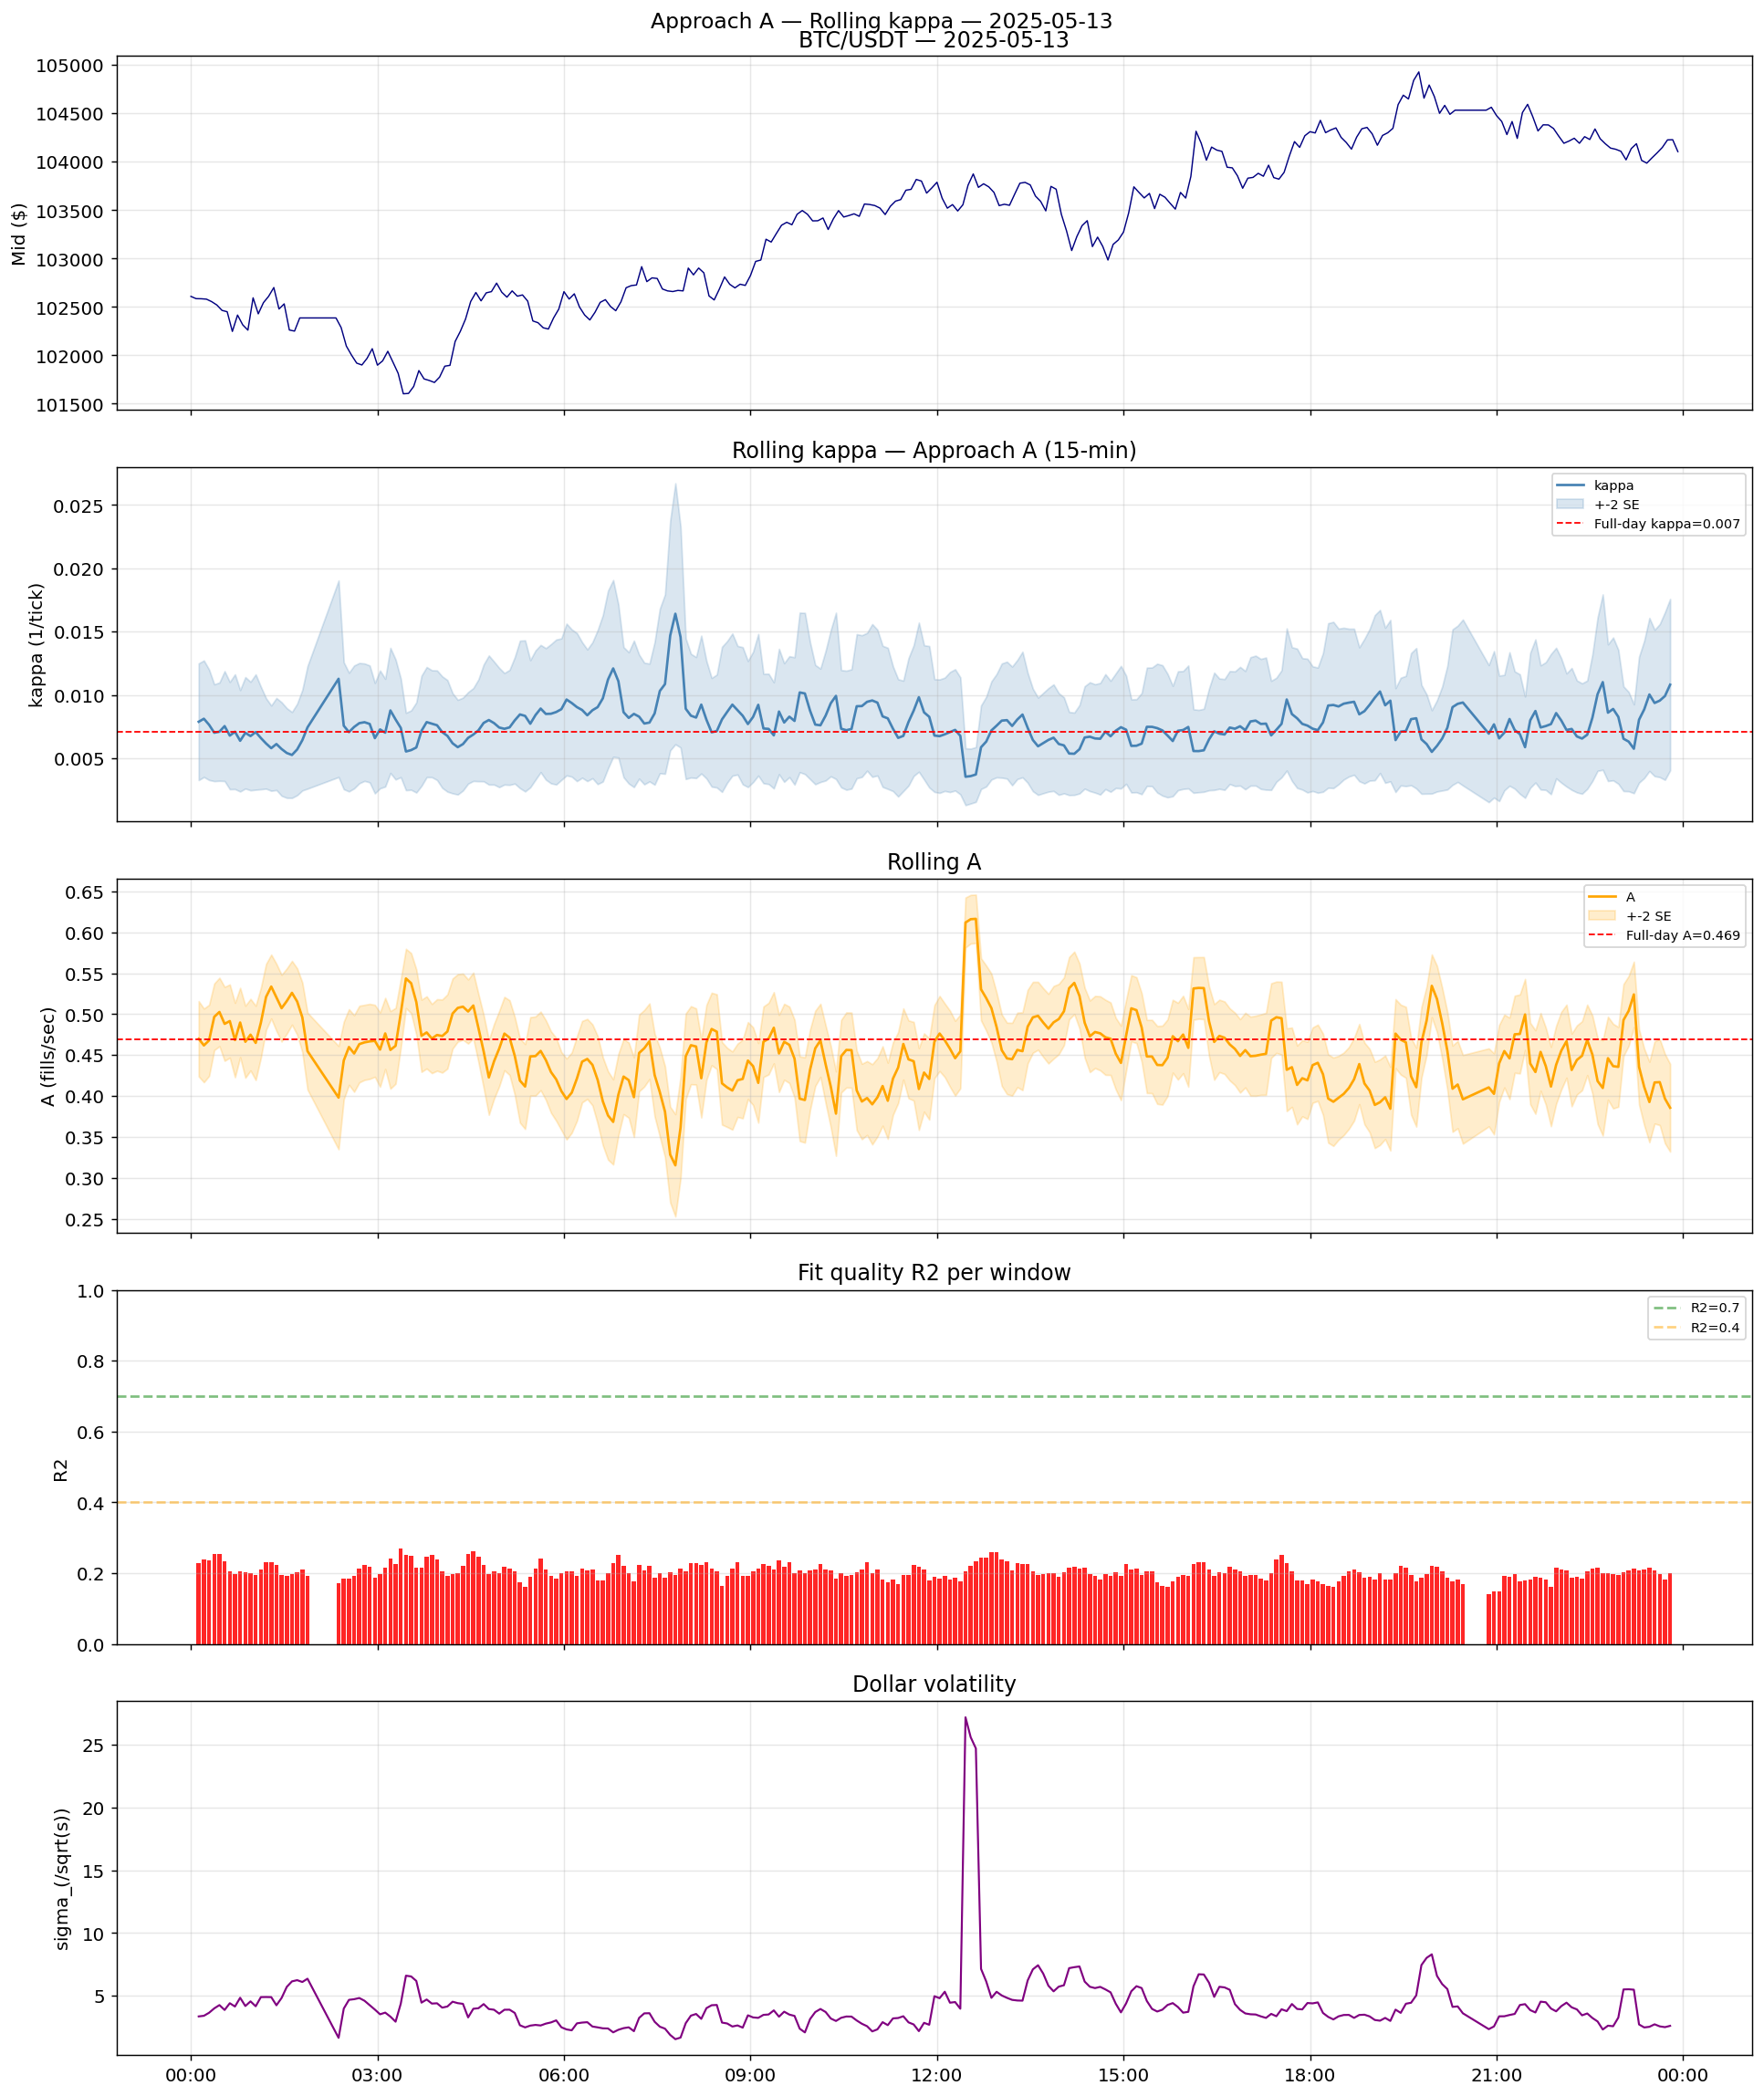

In [37]:
mid_resampled = quotes.set_index('ts')['mid'].resample('5min').last().ffill()
fmt = mdates.DateFormatter('%H:%M')

fig, axes = plt.subplots(5, 1, figsize=(15, 18), sharex=True)
ts = roll_A['window_mid']

axes[0].plot(mid_resampled.index, mid_resampled.values, lw=0.8, color='navy')
axes[0].set_ylabel('Mid ($)'); axes[0].set_title(f'BTC/USDT — {DATE}'); axes[0].grid(alpha=0.3)

axes[1].plot(ts, roll_A['kappa'], lw=1.5, color='steelblue', label='kappa')
axes[1].fill_between(ts,
    roll_A['kappa'] - 2*roll_A['se_kappa'],
    roll_A['kappa'] + 2*roll_A['se_kappa'],
    alpha=0.2, color='steelblue', label='+-2 SE')
axes[1].axhline(kappa_hat, color='red', ls='--', lw=1, label=f'Full-day kappa={kappa_hat:.3f}')
axes[1].set_ylabel('kappa (1/tick)'); axes[1].set_title(f'Rolling kappa — Approach A ({ROLL_WINDOW}-min)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(ts, roll_A['A'], lw=1.5, color='orange', label='A')
axes[2].fill_between(ts,
    roll_A['A'] - 2*roll_A['se_A'],
    roll_A['A'] + 2*roll_A['se_A'],
    alpha=0.2, color='orange', label='+-2 SE')
axes[2].axhline(A_hat, color='red', ls='--', lw=1, label=f'Full-day A={A_hat:.3f}')
axes[2].set_ylabel('A (fills/sec)'); axes[2].set_title('Rolling A')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

r2_colors = ['green' if r > 0.7 else 'orange' if r > 0.4 else 'red' for r in roll_A['r2']]
axes[3].bar(ts, roll_A['r2'], width=pd.Timedelta(minutes=4), color=r2_colors, alpha=0.85, edgecolor='none')
axes[3].axhline(0.7, color='green', ls='--', alpha=0.5, label='R2=0.7')
axes[3].axhline(0.4, color='orange', ls='--', alpha=0.5, label='R2=0.4')
axes[3].set_ylim(0, 1); axes[3].set_ylabel('R2'); axes[3].set_title('Fit quality R2 per window')
axes[3].legend(fontsize=8); axes[3].grid(alpha=0.3, axis='y')

axes[4].plot(ts, roll_A['sigma_dollar'], lw=1.2, color='purple')
axes[4].set_ylabel('sigma_$ ($/sqrt(s))'); axes[4].set_title('Dollar volatility')
axes[4].grid(alpha=0.3); axes[4].xaxis.set_major_formatter(fmt)

plt.suptitle(f'Approach A — Rolling kappa — {DATE}', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/kappa_rolling_A_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

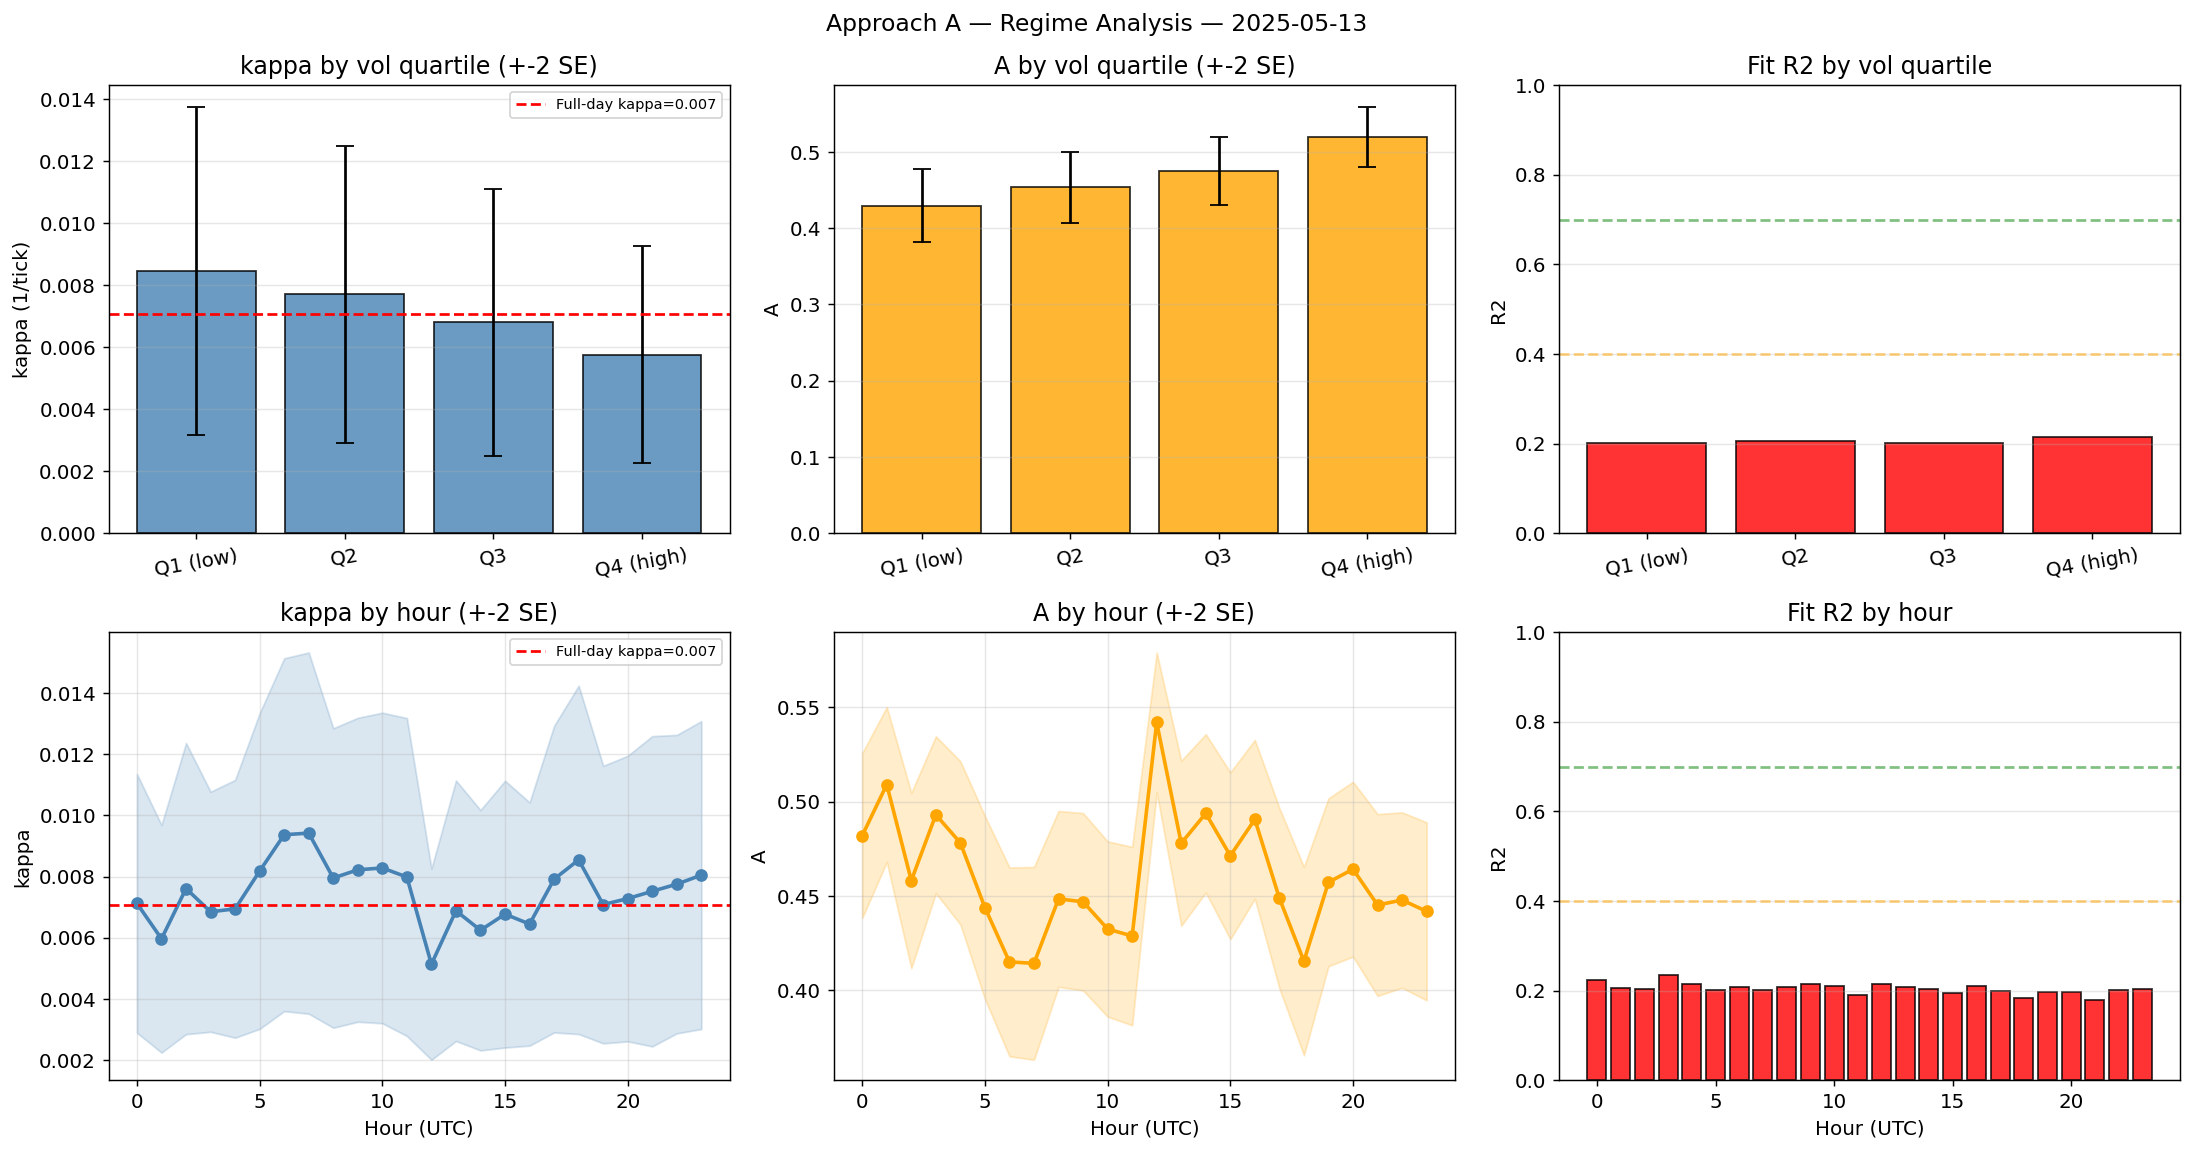

In [38]:
# Regime plots — vol quartile and hourly with R2
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
x = np.arange(len(vol_df))
vq_labels = vol_df['vol_quartile'].tolist()

axes[0,0].bar(x, vol_df['kappa'], yerr=2*vol_df['se_kappa'],
               capsize=5, color='steelblue', alpha=0.8, edgecolor='black')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(vq_labels, rotation=10)
axes[0,0].axhline(kappa_hat, color='red', ls='--', label=f'Full-day kappa={kappa_hat:.3f}')
axes[0,0].set_ylabel('kappa (1/tick)'); axes[0,0].set_title('kappa by vol quartile (+-2 SE)')
axes[0,0].legend(fontsize=8); axes[0,0].grid(alpha=0.3, axis='y')

axes[0,1].bar(x, vol_df['A'], yerr=2*vol_df['se_A'],
               capsize=5, color='orange', alpha=0.8, edgecolor='black')
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(vq_labels, rotation=10)
axes[0,1].set_ylabel('A'); axes[0,1].set_title('A by vol quartile (+-2 SE)')
axes[0,1].grid(alpha=0.3, axis='y')

r2_bar = ['green' if r > 0.7 else 'orange' if r > 0.4 else 'red' for r in vol_df['r2']]
axes[0,2].bar(x, vol_df['r2'], color=r2_bar, alpha=0.8, edgecolor='black')
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(vq_labels, rotation=10)
axes[0,2].axhline(0.7, color='green', ls='--', alpha=0.5)
axes[0,2].axhline(0.4, color='orange', ls='--', alpha=0.5)
axes[0,2].set_ylim(0, 1); axes[0,2].set_ylabel('R2')
axes[0,2].set_title('Fit R2 by vol quartile'); axes[0,2].grid(alpha=0.3, axis='y')

axes[1,0].plot(hour_df['hour'], hour_df['kappa'], 'o-', color='steelblue', lw=2)
axes[1,0].fill_between(hour_df['hour'],
    hour_df['kappa'] - 2*hour_df['se_kappa'],
    hour_df['kappa'] + 2*hour_df['se_kappa'],
    alpha=0.2, color='steelblue')
axes[1,0].axhline(kappa_hat, color='red', ls='--', label=f'Full-day kappa={kappa_hat:.3f}')
axes[1,0].set_xlabel('Hour (UTC)'); axes[1,0].set_ylabel('kappa')
axes[1,0].set_title('kappa by hour (+-2 SE)'); axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(hour_df['hour'], hour_df['A'], 'o-', color='orange', lw=2)
axes[1,1].fill_between(hour_df['hour'],
    hour_df['A'] - 2*hour_df['se_A'],
    hour_df['A'] + 2*hour_df['se_A'],
    alpha=0.2, color='orange')
axes[1,1].set_xlabel('Hour (UTC)'); axes[1,1].set_ylabel('A')
axes[1,1].set_title('A by hour (+-2 SE)'); axes[1,1].grid(alpha=0.3)

r2_h = ['green' if r > 0.7 else 'orange' if r > 0.4 else 'red' for r in hour_df['r2']]
axes[1,2].bar(hour_df['hour'], hour_df['r2'], color=r2_h, alpha=0.8, edgecolor='black')
axes[1,2].axhline(0.7, color='green', ls='--', alpha=0.5)
axes[1,2].axhline(0.4, color='orange', ls='--', alpha=0.5)
axes[1,2].set_ylim(0, 1); axes[1,2].set_xlabel('Hour (UTC)'); axes[1,2].set_ylabel('R2')
axes[1,2].set_title('Fit R2 by hour'); axes[1,2].grid(alpha=0.3, axis='y')

plt.suptitle(f'Approach A — Regime Analysis — {DATE}', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/kappa_regimes_A_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Approach B — Execution-Aware Simulation

Place synthetic limit orders at every `QUOTE_INTERVAL` respecting `LATENCY`.
Exposure window = `[t + latency, t + quote_interval + latency]` = `QUOTE_INTERVAL` seconds.
Count fraction of cycles where a real trade would have filled the order.

This gives a κ calibrated to **your specific latency and requote frequency**.

In [39]:
print(f'Approach B — execution simulation')
print(f'  Latency:         {LATENCY}s')
print(f'  Quote interval:  {QUOTE_INTERVAL}s')
print(f'  Exposure window: {QUOTE_INTERVAL}s  '
      f'(t+{LATENCY}s to t+{QUOTE_INTERVAL+LATENCY}s)')
print(f'  Sweeping delta = 0.5 to {MAX_DELTA_TICKS} ticks...')
print()

fp_B = simulate_fill_curve(trades, quotes)

A_B, kappa_B, se_A_B, se_kappa_B, r2_B = fit_exponential(fp_B, min_delta=0.5)

print(f'\nApproach B — simulation fit:')
print(f'  A     = {A_B:.4f}  (+-{se_A_B:.4f})')
print(f'  kappa = {kappa_B:.4f}  (+-{se_kappa_B:.4f})  [1/tick]')
print(f'  R2    = {r2_B:.4f}')
print(f'  Halves every {np.log(2)/kappa_B:.2f} ticks')

Approach B — execution simulation
  Latency:         0.1s
  Quote interval:  0.5s
  Exposure window: 0.5s  (t+0.1s to t+0.6s)
  Sweeping delta = 0.5 to 40 ticks...

  delta=0.5 ticks: fill_rate=0.6916
  delta=1.5 ticks: fill_rate=0.1540
  delta=2.5 ticks: fill_rate=0.1522
  delta=3.5 ticks: fill_rate=0.1519
  delta=4.5 ticks: fill_rate=0.1517
  delta=5.5 ticks: fill_rate=0.1516
  delta=6.5 ticks: fill_rate=0.1515
  delta=7.5 ticks: fill_rate=0.1514
  delta=8.5 ticks: fill_rate=0.1513
  delta=9.5 ticks: fill_rate=0.1513
  delta=10.5 ticks: fill_rate=0.1512
  delta=11.5 ticks: fill_rate=0.1511
  delta=12.5 ticks: fill_rate=0.1510
  delta=13.5 ticks: fill_rate=0.1510
  delta=14.5 ticks: fill_rate=0.1509
  delta=15.5 ticks: fill_rate=0.1508
  delta=16.5 ticks: fill_rate=0.1508
  delta=17.5 ticks: fill_rate=0.1507
  delta=18.5 ticks: fill_rate=0.1506
  delta=19.5 ticks: fill_rate=0.1505
  delta=20.5 ticks: fill_rate=0.1505
  delta=21.5 ticks: fill_rate=0.1503
  delta=22.5 ticks: fill_rate=0

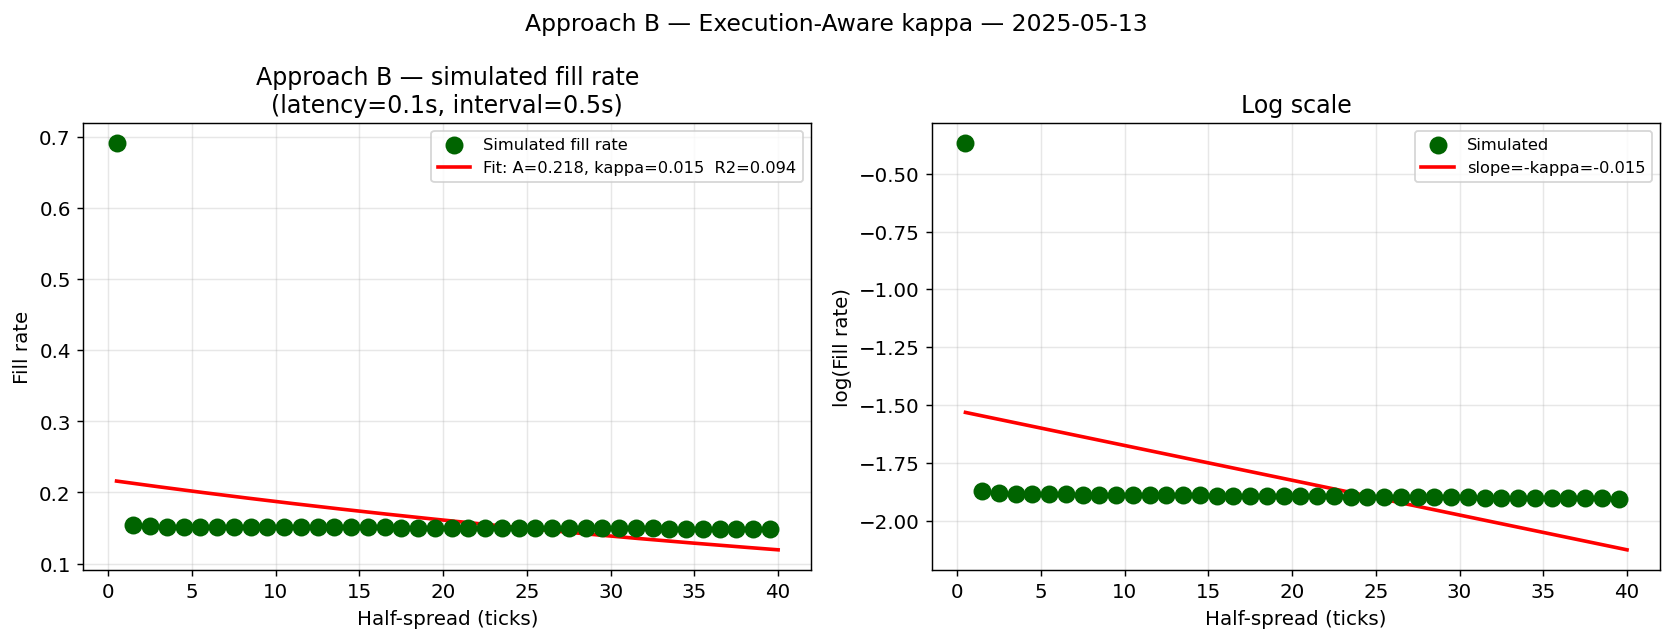

In [40]:
delta_range = np.linspace(0.5, MAX_DELTA_TICKS, 300)
fitted_B    = A_B * np.exp(-kappa_B * delta_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(fp_B['delta'], fp_B['fill_prob'], s=80, zorder=3, color='darkgreen', label='Simulated fill rate')
axes[0].plot(delta_range, fitted_B, 'r-', lw=2,
             label=f'Fit: A={A_B:.3f}, kappa={kappa_B:.3f}  R2={r2_B:.3f}')
axes[0].set_xlabel('Half-spread (ticks)')
axes[0].set_ylabel('Fill rate')
axes[0].set_title(f'Approach B — simulated fill rate\n(latency={LATENCY}s, interval={QUOTE_INTERVAL}s)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

valid_B = fp_B[fp_B['fill_prob'] > 0]
axes[1].scatter(valid_B['delta'], np.log(valid_B['fill_prob']), s=80, zorder=3, color='darkgreen', label='Simulated')
axes[1].plot(delta_range, np.log(fitted_B + 1e-10), 'r-', lw=2, label=f'slope=-kappa=-{kappa_B:.3f}')
axes[1].set_xlabel('Half-spread (ticks)')
axes[1].set_ylabel('log(Fill rate)')
axes[1].set_title('Log scale')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle(f'Approach B — Execution-Aware kappa — {DATE}', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/kappa_fit_B_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Rolling Approach B
print(f'Rolling Approach B — {ROLL_WINDOW}-min windows (slower)...')

roll_B_results = []
t_min = trades['ts'].min()
t_max = trades['ts'].max()
window = pd.Timedelta(minutes=ROLL_WINDOW)
step   = pd.Timedelta(minutes=ROLL_STEP)
t = t_min

while t + window <= t_max:
    t_end = t + window
    sub_trades = trades[(trades['ts'] >= t) & (trades['ts'] < t_end)]
    sub_quotes = quotes[
        (quotes['ts'] >= t - pd.Timedelta(seconds=5)) &
        (quotes['ts'] < t_end + pd.Timedelta(seconds=5))
    ]

    if len(sub_trades) < MIN_TRADES or len(sub_quotes) < 10:
        t += step
        continue

    fp_sub = simulate_fill_curve(sub_trades, sub_quotes,
                                  deltas=np.arange(0.5, MAX_DELTA_TICKS + 0.5, 1.0),
                                  verbose=False)
    A, k, se_A_r, se_k_r, r2_r = fit_exponential(fp_sub, min_delta=0.5)

    if k is not None:
        sub_merged = compute_fill_curve(sub_trades, sub_quotes)
        sigma_d = sub_merged['sigma_dollar'].mean() if len(sub_merged) > 0 else np.nan
        roll_B_results.append({
            'window_mid':   t + window / 2,
            'A': A, 'kappa': k,
            'se_A': se_A_r, 'se_kappa': se_k_r,
            'r2': r2_r, 'n': len(sub_trades),
            'sigma_dollar': sigma_d,
        })
        print(f'  {(t+window/2).strftime("%H:%M")}  '
              f'kappa={k:.3f}(+-{se_k_r:.3f})  A={A:.3f}  R2={r2_r:.3f}')
    t += step

roll_B = pd.DataFrame(roll_B_results)
if len(roll_B) > 0:
    roll_B['window_mid'] = pd.to_datetime(roll_B['window_mid'])
    print(f'\nRoll B — kappa mean={roll_B["kappa"].mean():.4f}  '
          f'std={roll_B["kappa"].std():.4f}  '
          f'CV={roll_B["kappa"].std()/roll_B["kappa"].mean():.3f}')

Rolling Approach B — 15-min windows (slower)...
  00:07  kappa=1.242(+-0.513)  A=1.286  R2=-0.542
  00:12  kappa=0.015(+-0.007)  A=0.217  R2=0.102
  00:17  kappa=0.015(+-0.007)  A=0.208  R2=0.105
  00:22  kappa=0.013(+-0.006)  A=0.222  R2=0.100
  00:27  kappa=0.012(+-0.006)  A=0.221  R2=0.093
  00:32  kappa=0.013(+-0.006)  A=0.232  R2=0.092
  00:37  kappa=0.015(+-0.007)  A=0.220  R2=0.091
  00:42  kappa=0.015(+-0.007)  A=0.233  R2=0.094
  00:47  kappa=0.013(+-0.006)  A=0.236  R2=0.092
  00:52  kappa=0.015(+-0.007)  A=0.204  R2=0.091
  00:57  kappa=0.010(+-0.005)  A=0.242  R2=0.090
  01:02  kappa=0.011(+-0.006)  A=0.227  R2=0.090
  01:07  kappa=0.009(+-0.004)  A=0.266  R2=0.087
  01:12  kappa=0.009(+-0.005)  A=0.239  R2=0.088
  01:17  kappa=0.010(+-0.005)  A=0.238  R2=0.091
  01:22  kappa=0.009(+-0.005)  A=0.227  R2=0.089
  01:27  kappa=0.007(+-0.004)  A=0.256  R2=0.084
  01:32  kappa=0.005(+-0.003)  A=0.307  R2=0.086
  01:37  kappa=0.006(+-0.003)  A=0.339  R2=0.090
  01:42  kappa=0.006

## 6. Comparison A vs B

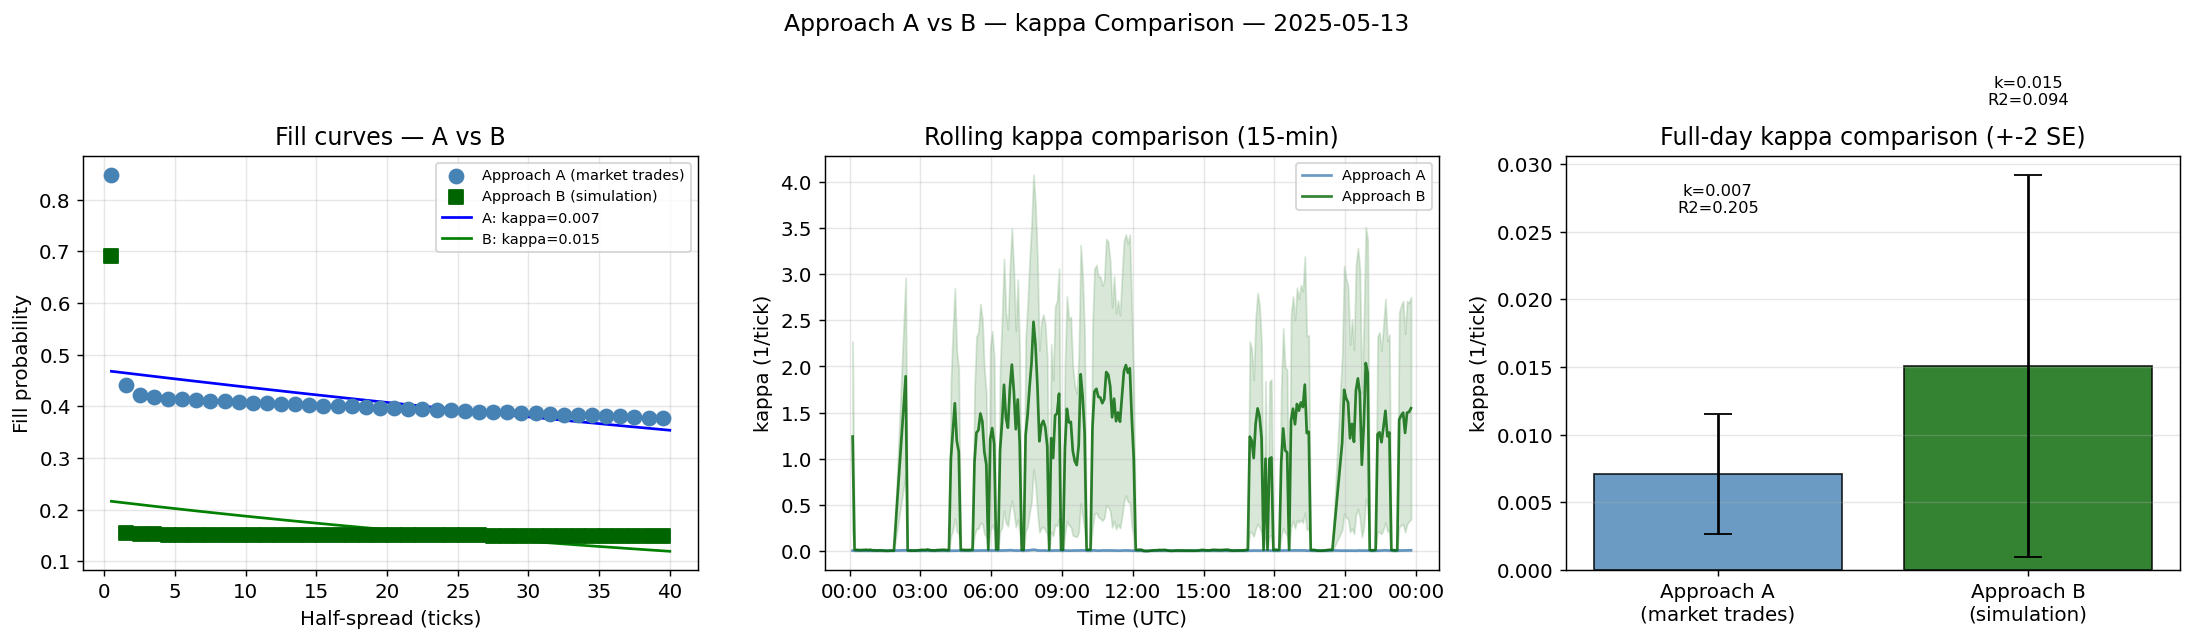

Approach A:  kappa=0.0071  A=0.4694  R2=0.2053
Approach B:  kappa=0.0150    A=0.2177  R2=0.0943
Ratio B/A:   kappa=2.12x  A=0.46x


In [42]:
delta_range   = np.linspace(0.5, MAX_DELTA_TICKS, 300)
fitted_A_line = A_hat * np.exp(-kappa_hat * delta_range)
fitted_B_line = A_B   * np.exp(-kappa_B   * delta_range)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Overlay fill curves
axes[0].scatter(fp_A['delta'], fp_A['fill_prob'], s=60, color='steelblue',
                zorder=3, label='Approach A (market trades)')
axes[0].scatter(fp_B['delta'], fp_B['fill_prob'], s=60, color='darkgreen',
                marker='s', zorder=3, label='Approach B (simulation)')
axes[0].plot(delta_range, fitted_A_line, 'b-', lw=1.5, label=f'A: kappa={kappa_hat:.3f}')
axes[0].plot(delta_range, fitted_B_line, 'g-', lw=1.5, label=f'B: kappa={kappa_B:.3f}')
axes[0].set_xlabel('Half-spread (ticks)')
axes[0].set_ylabel('Fill probability')
axes[0].set_title('Fill curves — A vs B')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Rolling kappa both approaches
axes[1].plot(roll_A['window_mid'], roll_A['kappa'], lw=1.5, color='steelblue', alpha=0.8, label='Approach A')
axes[1].fill_between(roll_A['window_mid'],
    roll_A['kappa'] - 2*roll_A['se_kappa'],
    roll_A['kappa'] + 2*roll_A['se_kappa'],
    alpha=0.15, color='steelblue')
if len(roll_B) > 0:
    axes[1].plot(roll_B['window_mid'], roll_B['kappa'], lw=1.5, color='darkgreen', alpha=0.8, label='Approach B')
    axes[1].fill_between(roll_B['window_mid'],
        roll_B['kappa'] - 2*roll_B['se_kappa'],
        roll_B['kappa'] + 2*roll_B['se_kappa'],
        alpha=0.15, color='darkgreen')
axes[1].set_xlabel('Time (UTC)')
axes[1].set_ylabel('kappa (1/tick)')
axes[1].set_title(f'Rolling kappa comparison ({ROLL_WINDOW}-min)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Summary bar
methods = ['Approach A\n(market trades)', 'Approach B\n(simulation)']
kappas  = [kappa_hat, kappa_B]
ses     = [se_kappa,  se_kappa_B]
r2s     = [r2,        r2_B]
colors  = ['steelblue', 'darkgreen']
bars = axes[2].bar(methods, kappas, yerr=[2*s for s in ses],
                    capsize=8, color=colors, alpha=0.8, edgecolor='black')
for bar, k, r in zip(bars, kappas, r2s):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(ses)*2 + 0.005,
                 f'k={k:.3f}\nR2={r:.3f}',
                 ha='center', va='bottom', fontsize=9)
axes[2].set_ylabel('kappa (1/tick)')
axes[2].set_title('Full-day kappa comparison (+-2 SE)')
axes[2].grid(alpha=0.3, axis='y')

plt.suptitle(f'Approach A vs B — kappa Comparison — {DATE}', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/kappa_comparison_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Approach A:  kappa={kappa_hat:.4f}  A={A_hat:.4f}  R2={r2:.4f}')
print(f'Approach B:  kappa={kappa_B:.4f}    A={A_B:.4f}  R2={r2_B:.4f}')
print(f'Ratio B/A:   kappa={kappa_B/kappa_hat:.2f}x  A={A_B/A_hat:.2f}x')

## 7. GLFT Plug-in — Implied Spreads

In [43]:
mid_price = quotes['mid'].median()
sigma_est = merged_all['sigma_dollar'].median() / mid_price

print(f'Median mid:  ${mid_price:.2f}')
print(f'Median sigma_$:  ${sigma_est * mid_price:.4f}/sqrt(s)')
print()

for approach_name, A_use, k_use in [
    ('Approach A', A_hat, kappa_hat),
    ('Approach B', A_B,   kappa_B),
]:
    print(f'{'='*60}')
    print(f'{approach_name}  A={A_use:.4f}  kappa={k_use:.4f}')
    print(f'{'='*60}')
    print(f'{"gamma":>6} {"inv":>7} {"reserv":>12} {"hs($)":>8} {"bps":>8} {"adv%":>7} {"inv%":>7}')
    print('-' * 60)
    for gamma in [ 0.01, 0.1,0.5]:
        strat = GLFTMarketMaker(
            gamma=gamma, A=A_use, kappa=k_use,
            order_size=0.001, min_spread_bps=0.01,
            max_inventory=0.2, tick_size=TICK, kappa_from_stats=False,
        )
        for inv in [-0.02, 0.0, 0.02]:
            r  = strat.reservation_price(mid_price, inv, sigma_est, A_use)
            hs, adv, inv_t = strat.optimal_half_spread(sigma_est, mid_price, A_use)
            bps = hs * 2 / mid_price * 10000
            ap = adv / hs * 100 if hs > 0 else 0
            ip = inv_t / hs * 100 if hs > 0 else 0
            print(f'{gamma:>6} {inv:>7.3f} {r:>12.4f} {hs:>8.4f} {bps:>8.4f} {ap:>6.1f}% {ip:>6.1f}%')
    print()

Median mid:  $103511.20
Median sigma_$:  $4.2325/sqrt(s)

Approach A  A=0.4694  kappa=0.0071
 gamma     inv       reserv    hs($)      bps    adv%    inv%
------------------------------------------------------------
  0.01  -0.020  103511.7391  79.7123  15.4017   94.9%    5.1%
  0.01   0.000  103511.2000  79.7123  15.4017   94.9%    5.1%
  0.01   0.020  103510.6609  79.7123  15.4017   94.9%    5.1%
   0.1  -0.020  103516.5912  18.1772   3.5121   53.2%   46.8%
   0.1   0.000  103511.2000  18.1772   3.5121   53.2%   46.8%
   0.1   0.020  103505.8088  18.1772   3.5121   53.2%   46.8%
   0.5  -0.020  103538.1558  20.4734   3.9558    9.7%   90.3%
   0.5   0.000  103511.2000  20.4734   3.9558    9.7%   90.3%
   0.5   0.020  103484.2442  20.4734   3.9558    9.7%   90.3%

Approach B  A=0.2177  kappa=0.0150
 gamma     inv       reserv    hs($)      bps    adv%    inv%
------------------------------------------------------------
  0.01  -0.020  103511.7472  69.2847  13.3869   88.1%   11.9%
  0.0

## 8. Summary

In [44]:
print('=' * 65)
print('KAPPA ESTIMATION SUMMARY')
print('=' * 65)
print(f'Date:                    {DATE}')
print(f'Tick size:               ${TICK}')
print(f'Fit range:               0.5 - {MAX_DELTA_TICKS} ticks')
print(f'Quote age filter:        < {MAX_QUOTE_AGE} ms')
print(f'Rolling window:          {ROLL_WINDOW} min  (step {ROLL_STEP} min)')
print(f'Execution:               latency={LATENCY}s  interval={QUOTE_INTERVAL}s')
print()
print(f'APPROACH A — market trade curve:')
print(f'  A       = {A_hat:.4f}  (+-{se_A:.4f})')
print(f'  kappa   = {kappa_hat:.4f}  (+-{se_kappa:.4f})')
print(f'  R2      = {r2:.4f}')
print(f'  Halves every {np.log(2)/kappa_hat:.2f} ticks')
print(f'  Rolling kappa CV = {roll_A["kappa"].std()/roll_A["kappa"].mean():.3f}')
print()
print(f'APPROACH B — execution simulation:')
print(f'  A       = {A_B:.4f}  (+-{se_A_B:.4f})')
print(f'  kappa   = {kappa_B:.4f}  (+-{se_kappa_B:.4f})')
print(f'  R2      = {r2_B:.4f}')
print(f'  Halves every {np.log(2)/kappa_B:.2f} ticks')
if len(roll_B) > 0:
    print(f'  Rolling kappa CV = {roll_B["kappa"].std()/roll_B["kappa"].mean():.3f}')
print()
rec_name  = 'B' if r2_B >= r2 else 'A'
rec_kappa = kappa_B if r2_B >= r2 else kappa_hat
rec_A_val = A_B     if r2_B >= r2 else A_hat
print(f'RECOMMENDATION: Use Approach {rec_name} (R2={max(r2, r2_B):.3f})')
print(f'  config.json:  "kappa": {rec_kappa:.4f}  "A": {rec_A_val:.4f}')

KAPPA ESTIMATION SUMMARY
Date:                    2025-05-13
Tick size:               $0.01
Fit range:               0.5 - 40 ticks
Quote age filter:        < 200 ms
Rolling window:          15 min  (step 5 min)
Execution:               latency=0.1s  interval=0.5s

APPROACH A — market trade curve:
  A       = 0.4694  (+-0.0222)
  kappa   = 0.0071  (+-0.0022)
  R2      = 0.2053
  Halves every 97.91 ticks
  Rolling kappa CV = 0.198

APPROACH B — execution simulation:
  A       = 0.2177  (+-0.0300)
  kappa   = 0.0150  (+-0.0071)
  R2      = 0.0943
  Halves every 46.10 ticks
  Rolling kappa CV = 1.088

RECOMMENDATION: Use Approach A (R2=0.205)
  config.json:  "kappa": 0.0071  "A": 0.4694


In [45]:
# Filter to high quality windows only
good_B = roll_B[roll_B['r2'] > 0.8].copy()
print(f'High quality windows (R2>0.8): {len(good_B)}/{len(roll_B)}')
print(f'kappa mean={good_B["kappa"].mean():.4f}  std={good_B["kappa"].std():.4f}')
print(f'Correlation with sigma: {good_B["kappa"].corr(good_B["sigma_dollar"]):.4f}')

# What time of day are they?
good_B['hour'] = pd.to_datetime(good_B['window_mid']).dt.hour
print(good_B.groupby('hour')[['kappa', 'r2', 'sigma_dollar']].mean().to_string())

High quality windows (R2>0.8): 0/276
kappa mean=nan  std=nan
Correlation with sigma: nan
Empty DataFrame
Columns: [kappa, r2, sigma_dollar]
Index: []


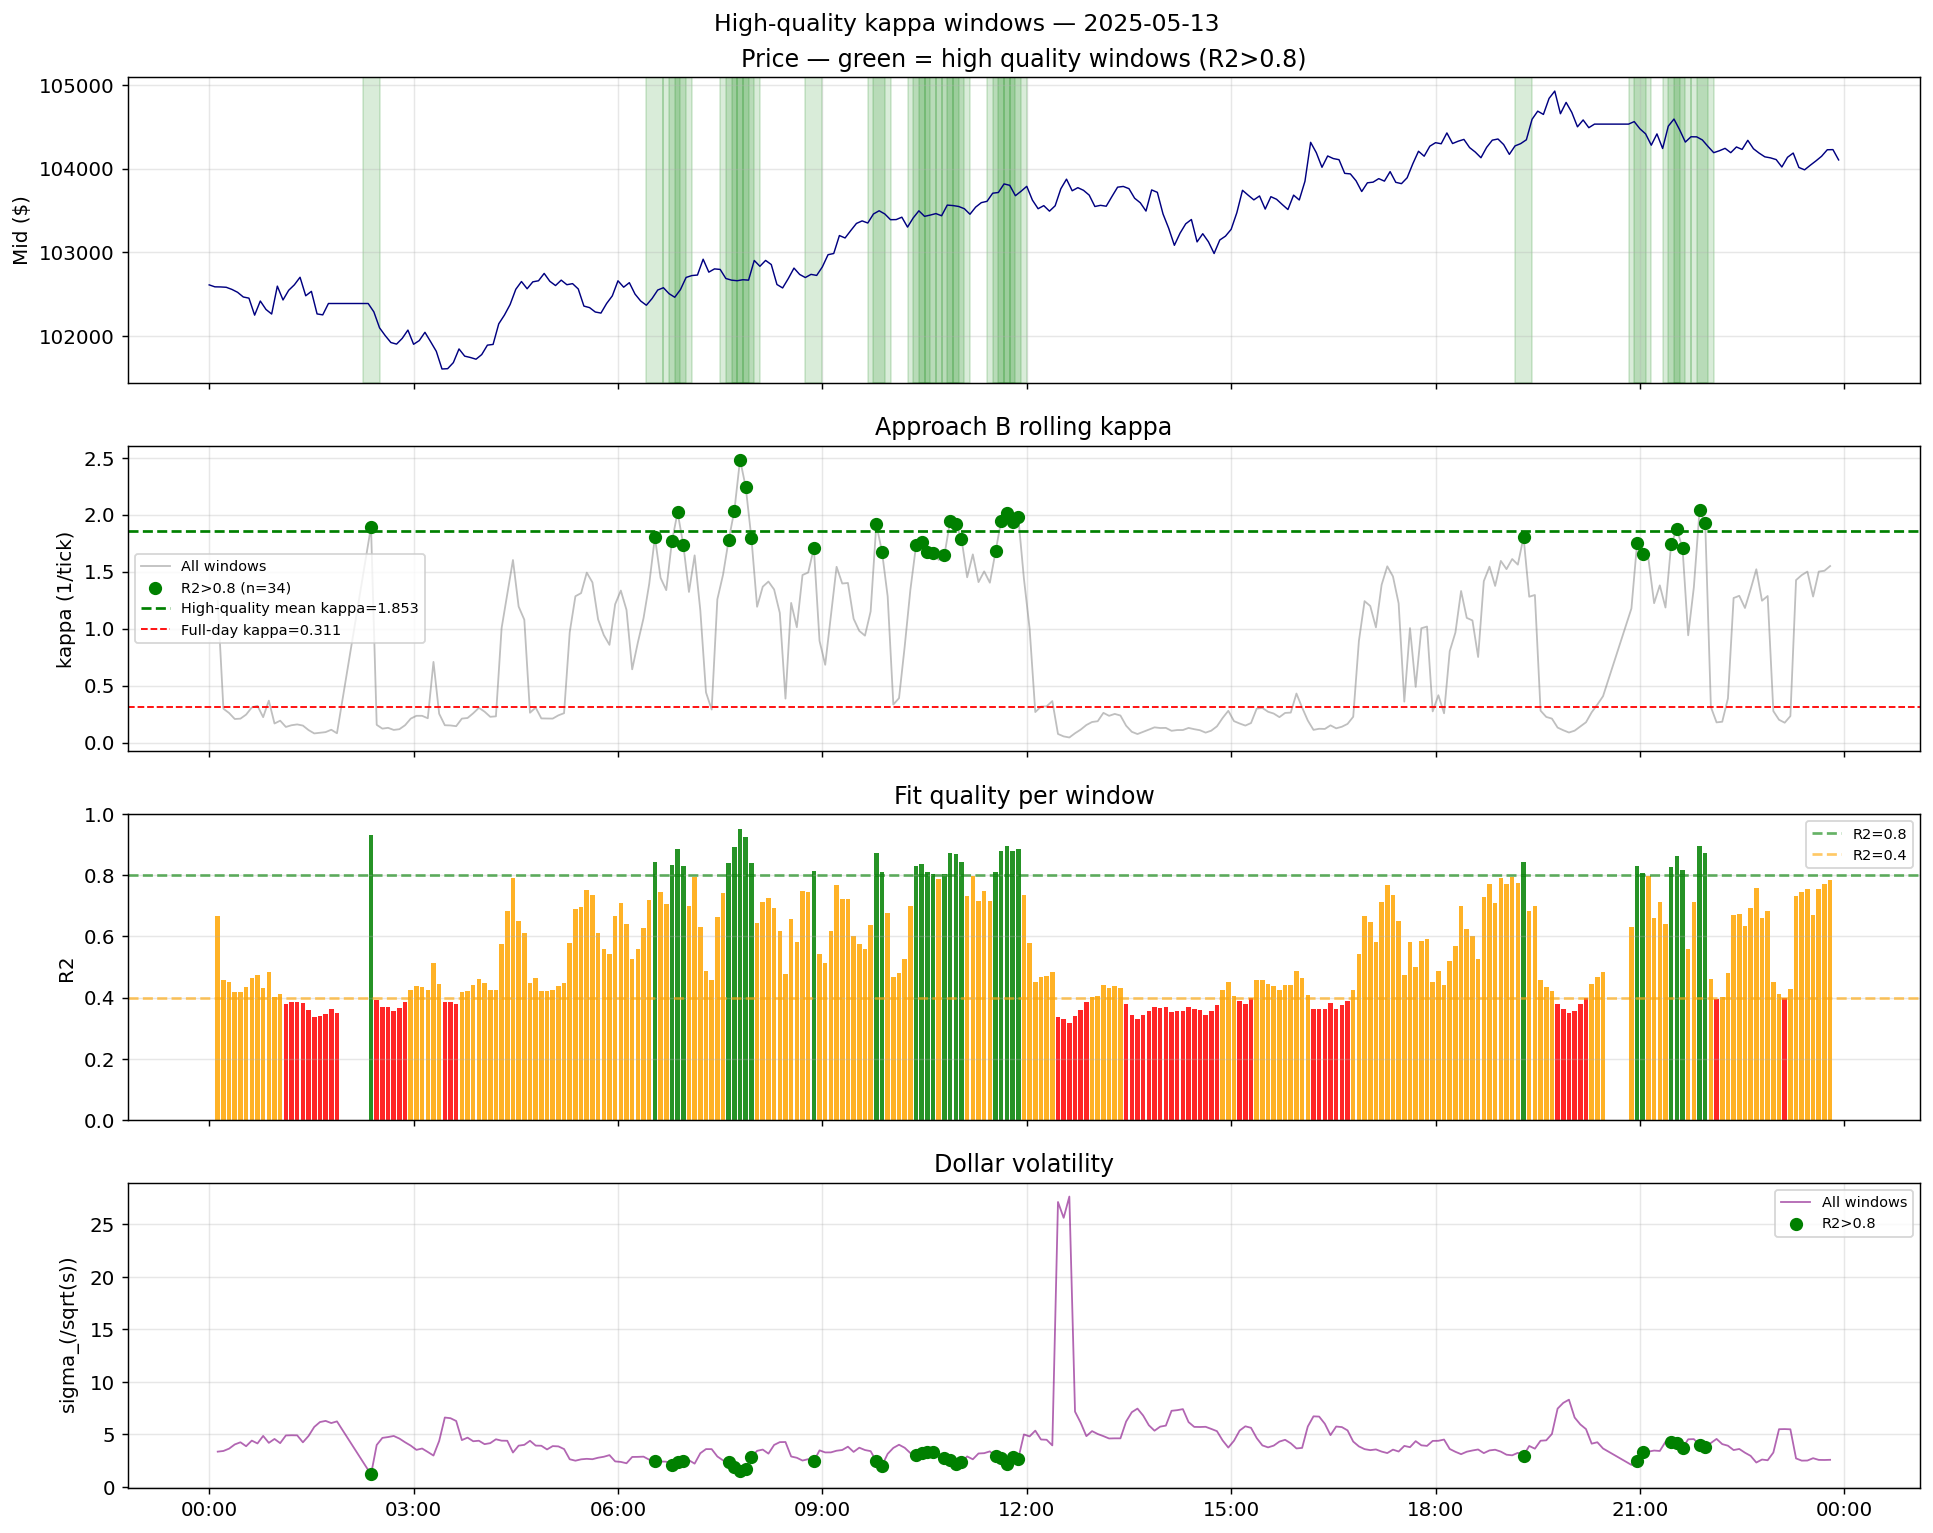

In [24]:
good_B['window_mid'] = pd.to_datetime(good_B['window_mid'], utc=True)

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
fmt = mdates.DateFormatter('%H:%M')

axes[0].plot(mid_resampled.index, mid_resampled.values, lw=0.8, color='navy')
for _, row in good_B.iterrows():
    axes[0].axvspan(row['window_mid'] - pd.Timedelta(minutes=7.5),
                    row['window_mid'] + pd.Timedelta(minutes=7.5),
                    alpha=0.15, color='green')
axes[0].set_ylabel('Mid ($)')
axes[0].set_title('Price — green = high quality windows (R2>0.8)')
axes[0].grid(alpha=0.3)

axes[1].plot(roll_B['window_mid'], roll_B['kappa'], lw=1, color='gray', alpha=0.5, label='All windows')
axes[1].scatter(good_B['window_mid'], good_B['kappa'],
                color='green', s=40, zorder=4, label=f'R2>0.8 (n={len(good_B)})')
axes[1].axhline(good_B['kappa'].mean(), color='green', ls='--', lw=1.5,
                label=f'High-quality mean kappa={good_B["kappa"].mean():.3f}')
axes[1].axhline(kappa_B, color='red', ls='--', lw=1, label=f'Full-day kappa={kappa_B:.3f}')
axes[1].set_ylabel('kappa (1/tick)')
axes[1].set_title('Approach B rolling kappa')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

r2_colors = ['green' if r > 0.8 else 'orange' if r > 0.4 else 'red' for r in roll_B['r2']]
axes[2].bar(roll_B['window_mid'], roll_B['r2'],
            width=pd.Timedelta(minutes=4), color=r2_colors, alpha=0.85, edgecolor='none')
axes[2].axhline(0.8, color='green', ls='--', alpha=0.6, label='R2=0.8')
axes[2].axhline(0.4, color='orange', ls='--', alpha=0.6, label='R2=0.4')
axes[2].set_ylim(0, 1); axes[2].set_ylabel('R2')
axes[2].set_title('Fit quality per window')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3, axis='y')

axes[3].plot(roll_B['window_mid'], roll_B['sigma_dollar'], lw=1, color='purple', alpha=0.6, label='All windows')
axes[3].scatter(good_B['window_mid'], good_B['sigma_dollar'],
                color='green', s=40, zorder=4, label='R2>0.8')
axes[3].set_ylabel('sigma_$ ($/sqrt(s))'); axes[3].set_title('Dollar volatility')
axes[3].legend(fontsize=8); axes[3].grid(alpha=0.3)
axes[3].xaxis.set_major_formatter(fmt)

plt.suptitle(f'High-quality kappa windows — {DATE}', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/high_quality_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
print('High-quality windows by hour:')
print(good_B.groupby('hour')[['kappa', 'r2', 'sigma_dollar', 'n']]
      .agg({'kappa': 'mean', 'r2': 'mean', 'sigma_dollar': 'mean', 'n': 'sum'})
      .round(4).to_string())

High-quality windows by hour:
       kappa      r2  sigma_dollar       n
hour                                      
2     1.8944  0.9303        1.1824     941
6     1.8311  0.8487        2.3286   69818
7     2.0669  0.8896        2.0720   82474
8     1.7058  0.8133        2.4650   16505
9     1.7959  0.8415        2.2311   41414
10    1.7606  0.8327        2.9368  155148
11    1.8904  0.8657        2.6211  135879
19    1.8036  0.8436        2.9771   26832
20    1.7480  0.8300        2.4893    6840
21    1.8234  0.8470        3.8796  105464


In [22]:
print(f'Final recommendation:')
print(f'  kappa (high-quality) = {good_B["kappa"].mean():.4f} +- {good_B["kappa"].std():.4f}')
print(f'  A     (high-quality) = {good_B["A"].mean():.4f} +- {good_B["A"].std():.4f}')
print(f'  Active hours:          {sorted(good_B["hour"].unique().tolist())}')
sigma_threshold = good_B['sigma_dollar'].quantile(0.75)
print(f'  sigma threshold:       ${sigma_threshold:.4f} (75th pct of good windows)')
print()
print(f'config.json recommendation:')
print(f'  "kappa": {good_B["kappa"].mean():.4f}')
print(f'  "A":     {good_B["A"].mean():.4f}')
print(f'  "active_hours": {sorted(good_B["hour"].unique().tolist())}')
print(f'  "sigma_dollar_threshold": {sigma_threshold:.4f}')

Final recommendation:
  kappa (high-quality) = 1.8532 +- 0.1798
  A     (high-quality) = 1.6279 +- 0.2653
  Active hours:          [2, 6, 7, 8, 9, 10, 11, 19, 20, 21]
  sigma threshold:       $3.1940 (75th pct of good windows)

config.json recommendation:
  "kappa": 1.8532
  "A":     1.6279
  "active_hours": [2, 6, 7, 8, 9, 10, 11, 19, 20, 21]
  "sigma_dollar_threshold": 3.1940


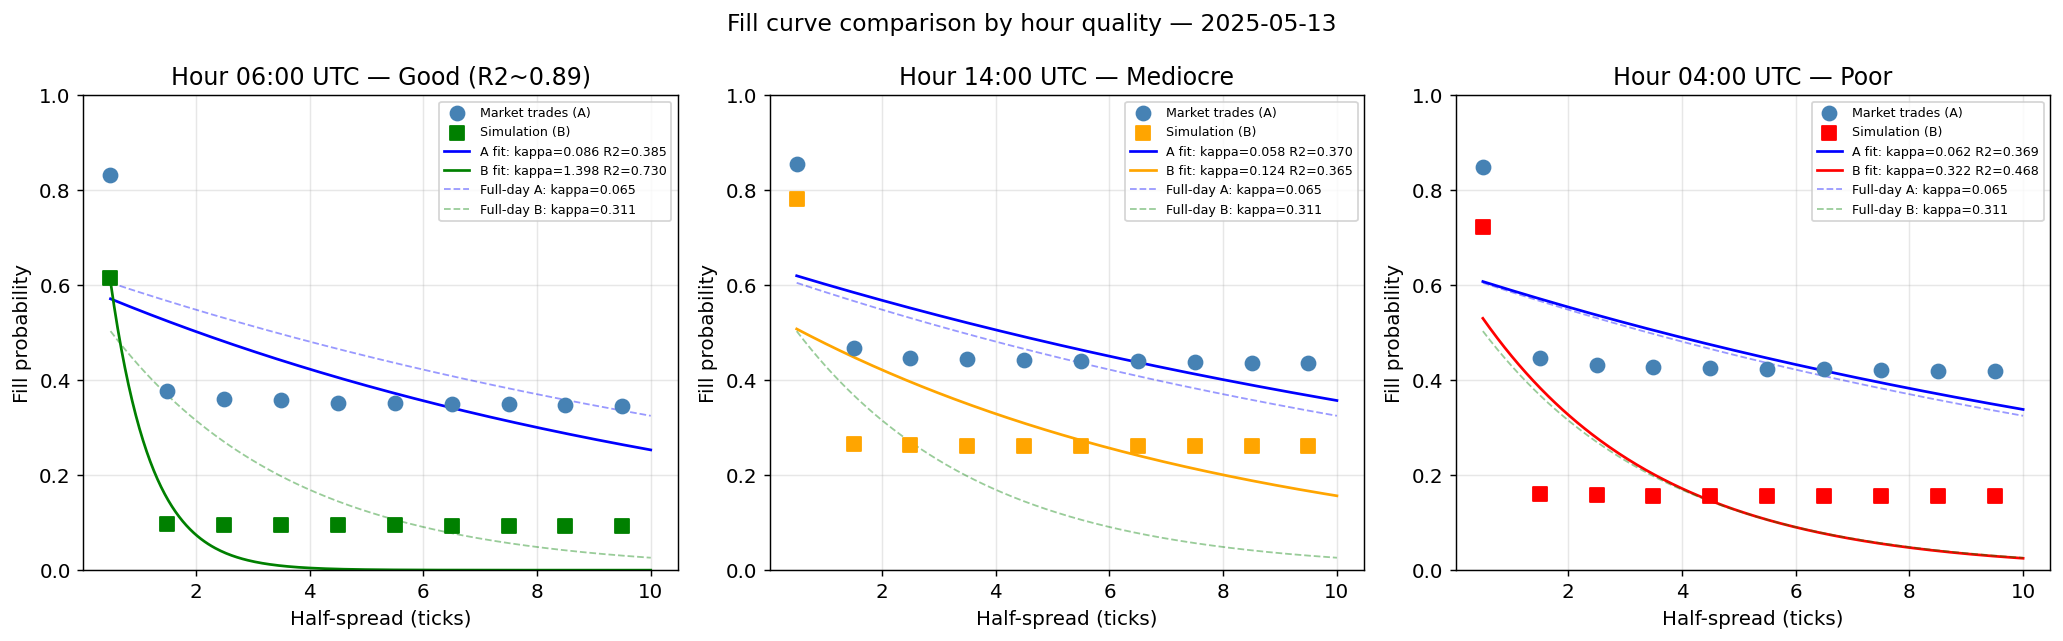

In [26]:
# Select one good hour, one mediocre, one poor for comparison
hours_to_plot = [
    (6,  'Good (R2~0.89)',    'green'),
    (14, 'Mediocre',          'orange'),
    (4,  'Poor',              'red'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

delta_range = np.linspace(0.5, MAX_DELTA_TICKS, 300)

for ax, (hour, label, color) in zip(axes, hours_to_plot):
    sub = merged_all[merged_all['hour'] == hour]
    if len(sub) < MIN_TRADES:
        ax.set_title(f'Hour {hour} — insufficient data')
        continue

    fp_sub = empirical_fill_prob(sub)
    A, k, se_A_h, se_k_h, r2_h = fit_exponential(fp_sub, min_delta=0.5)

    # Also run simulation for this hour
    sub_trades = trades[trades['ts'].dt.hour == hour]
    sub_quotes = quotes[
        (quotes['ts'].dt.hour >= hour - 1) &
        (quotes['ts'].dt.hour <= hour + 1)
    ]
    fp_sim = simulate_fill_curve(sub_trades, sub_quotes,
                                  deltas=np.arange(0.5, MAX_DELTA_TICKS + 0.5, 1.0),
                                  verbose=False)
    A_s, k_s, _, _, r2_s = fit_exponential(fp_sim, min_delta=0.5)

    # Plot empirical points
    ax.scatter(fp_sub['delta'], fp_sub['fill_prob'],
               s=60, color='steelblue', zorder=3, label='Market trades (A)')
    ax.scatter(fp_sim['delta'], fp_sim['fill_prob'],
               s=60, color=color, marker='s', zorder=3, label='Simulation (B)')

    # Plot fits
    if k is not None:
        ax.plot(delta_range, A * np.exp(-k * delta_range), 'b-', lw=1.5,
                label=f'A fit: kappa={k:.3f} R2={r2_h:.3f}')
    if k_s is not None:
        ax.plot(delta_range, A_s * np.exp(-k_s * delta_range),
                color=color, lw=1.5, ls='-',
                label=f'B fit: kappa={k_s:.3f} R2={r2_s:.3f}')

    # Full day reference
    ax.plot(delta_range, A_hat * np.exp(-kappa_hat * delta_range),
            'b--', lw=1, alpha=0.4, label=f'Full-day A: kappa={kappa_hat:.3f}')
    ax.plot(delta_range, A_B * np.exp(-kappa_B * delta_range),
            'g--', lw=1, alpha=0.4, label=f'Full-day B: kappa={kappa_B:.3f}')

    ax.set_xlabel('Half-spread (ticks)')
    ax.set_ylabel('Fill probability')
    ax.set_title(f'Hour {hour:02d}:00 UTC — {label}')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle(f'Fill curve comparison by hour quality — {DATE}', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/good_fits_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()